# Pipeline de Correção de Malha com CFD + ML + PINN
Estudo de caso Lid-Driven Cavity: [Doc OpenFoam Lid-Driven Cavity](https://doc.cfd.direct/openfoam/user-guide-v8/cavity)

O projeto consiste em um estudo de pesquisa sobre a relevância de se aplicar técnicas de Physics-Informed Neural Networks (PINNs) para otimizar o processo de refinamento de malha de simulações CFD.

### Descrição do Problema

O escoamento analisado é o **lid-driven cavity incompressível e laminar**, resolvido inicialmente via OpenFOAM. A simulação *coarse* é utilizada como entrada para modelos de ML que aprendem a corrigir o campo de velocidade, buscando maior acurácia e melhor consistência física.

**Configuração física principal:**

- Fluido incompressível e Newtoniano  
- Regime laminar  
- Solver: `icoFoam`  
- Número de Reynolds:
  
  \[
  Re = 10
  \]

---

### Domínio e Malha

- Geometria: cavidade quadrada 2D  
- Comprimento característico: \(L = 0.1\)  
- Malha *coarse*: **20 × 20**  
- Referência para avaliação: **40 × 40**

A bidimensionalidade é garantida via condição `empty` nas faces frontal e traseira.

---

### Condições de Contorno

- **Tampa móvel (`movingWall`):**
  - Velocidade imposta: `U = (1 0 0)`
- **Demais paredes:** condição de não deslizamento (*no-slip*)
- **Front and back:** `empty`

# Configuração de Ambiente
Pacotes necessários para o pipeline

In [20]:
# Inicializando o ambiente
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pyvista as pv
from __future__ import annotations
import torch.nn as nn
import torch
from torch.utils.data import DataLoader, TensorDataset
from pathlib import Path
from sklearn.model_selection import train_test_split

## Paraview - Simulações CFD
Visualização dos dados CSVs vindos do Plot Over Line, com colunas Points:1 (y) e U:0 (u), obtidos das simulações CFD, via OpenFoam, das malhas 20x20, 40x40 e 80x80.

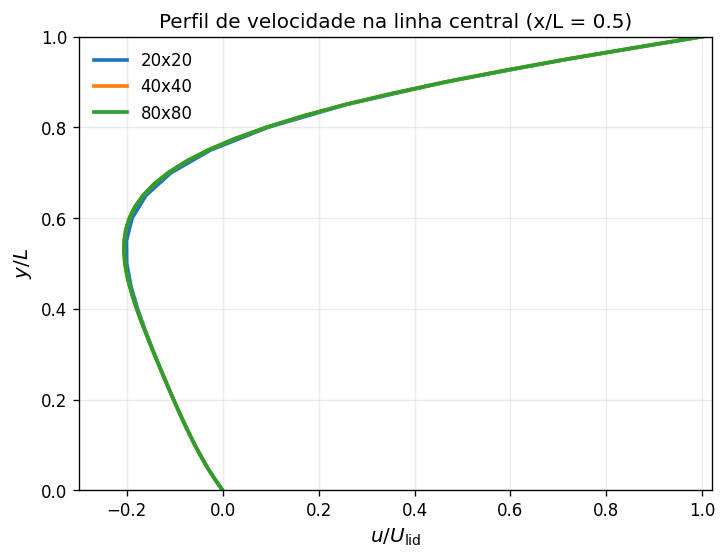

In [2]:
# --- Visualização dados CFD ---
L = 0.1        # tamanho do domínio
U_lid = 1.0    # velocidade da tampa

files = {
    "20x20": "/home/matheus/Documentos/Mestrado/Pesquisa/Lid_driven_cavity/data/cavity_20/lid_driven_cavity_20.csv",
    "40x40": "/home/matheus/Documentos/Mestrado/Pesquisa/Lid_driven_cavity/data/cavity_40/lid_driven_cavity_40.csv",
    "80x80": "/home/matheus/Documentos/Mestrado/Pesquisa/Lid_driven_cavity/data/cavity_80/lid_driven_cavity_80.csv",
}

plt.rcParams.update({
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "figure.dpi": 120,
})

fig, ax = plt.subplots(figsize=(6.2, 4.8))

# ------------------
# Plot
# ------------------
for label, path in files.items():
    df = pd.read_csv(path)

    y = df["Points:1"].to_numpy()
    u = df["U:0"].to_numpy()

    y_star = y / L
    u_star = u / U_lid

    idx = np.argsort(y_star)
    y_star = y_star[idx]
    u_star = u_star[idx]

    # Destaque visual: coarse com marcador leve (opcional)
    if label == "20×20":
        ax.plot(u_star, y_star, linewidth=2.2, marker="o", markersize=3, markevery=12, label=label)
    else:
        ax.plot(u_star, y_star, linewidth=2.2, label=label)

# ------------------
# Estilo e rótulos
# ------------------
ax.set_xlabel(r"$u/U_{\mathrm{lid}}$")
ax.set_ylabel(r"$y/L$")

ax.set_xlim(-0.30, 1.02)
ax.set_ylim(0.0, 1.0)

ax.grid(True, alpha=0.25)
ax.legend(frameon=False, loc="upper left")

# Título curto (opcional)
ax.set_title("Perfil de velocidade na linha central (x/L = 0.5)")

fig.tight_layout()

# ------------------
# Salvar figuras
# ------------------
fig.savefig("/home/matheus/Documentos/Mestrado/Pesquisa/Lid_driven_cavity/outputs/figures/centerline_convergence.pdf", bbox_inches="tight")   # ideal para dissertação
fig.savefig("/home/matheus/Documentos/Mestrado/Pesquisa/Lid_driven_cavity/outputs/figures/centerline_convergence.svg", bbox_inches="tight")   # ótimo para editar no Inkscape
fig.savefig("/home/matheus/Documentos/Mestrado/Pesquisa/Lid_driven_cavity/outputs/figures/centerline_convergence.png", dpi=300, bbox_inches="tight")

plt.show()

In [3]:
# Interpolando: erro L2 entre malhas 40x40 e 80x80
from scipy.interpolate import interp1d

df40 = pd.read_csv(files["40x40"])
df80 = pd.read_csv(files["80x80"])

y40 = df40["Points:1"].values / L
u40 = df40["U:0"].values
y80 = df80["Points:1"].values / L
u80 = df80["U:0"].values

f80 = interp1d(y80, u80, kind="linear", fill_value="extrapolate")
u80_interp = f80(y40)

l2_rel = np.linalg.norm(u40 - u80_interp) / np.linalg.norm(u80_interp)
print(f"Erro L2 relativo (40 vs 80): {l2_rel:.4e}")

Erro L2 relativo (40 vs 80): 1.0770e-19


Observa-se que o refinamento adicional da malha de 40×40 para 80×80 não resulta em alterações significativas no campo de velocidade, indicando que a solução já se encontra convergida em relação à discretização espacial.

# Pipeline Machine Learning
Fazendo a injestão dos dados brutos das simulações para começar o refinamento via modelo MLP.

In [4]:
# --- Pipeline preparação dados brutos simulação CFD ---

def create_df_cavity(mesh_path: str, df_output: str) -> None:
    mesh = pv.read(mesh_path)
    # junta todos os blocos
    mesh = mesh.combine()

    pts = mesh.points
    U = mesh.point_data["U"]
    p = mesh.point_data["p"]

    df = pd.DataFrame({
        "x": pts[:,0],
        "y": pts[:,1],
        "u": U[:,0],
        "v": U[:,1],
        "p": p
    })

    df.to_csv(df_output, index=False)

if __name__ == "__main__":
    create_df_cavity("/home/matheus/Documentos/Mestrado/Pesquisa/Lid_driven_cavity/CFD/cavity_coarse/VTK/cavity_coarse_100.vtm", 
                     "/home/matheus/Documentos/Mestrado/Pesquisa/Lid_driven_cavity/data/cavity_20/cavity_20_full.csv")
    print("Create cavity 20 done")
    create_df_cavity("/home/matheus/Documentos/Mestrado/Pesquisa/Lid_driven_cavity/CFD/cavity_fine/VTK/cavity_fine_80.vtm", 
                     "/home/matheus/Documentos/Mestrado/Pesquisa/Lid_driven_cavity/data/cavity_40/cavity_40_full.csv")
    print("Create cavity 40 done")
    create_df_cavity("/home/matheus/Documentos/Mestrado/Pesquisa/Lid_driven_cavity/CFD/cavity_ref/VTK/cavityRef_80.vtm", 
                     "/home/matheus/Documentos/Mestrado/Pesquisa/Lid_driven_cavity/data/cavity_80/cavity_80_full.csv")
    print("Create cavity 80 done")

Create cavity 20 done
Create cavity 40 done
Create cavity 80 done


## ETL dos dados obtidos pela Simulação CFD

In [5]:
# --- Formatando dados brutos CFD para ML ---

# -----------------------
# Config
# -----------------------
CSV_PATH_20 = Path("/home/matheus/Documentos/Mestrado/Pesquisa/Lid_driven_cavity/data/cavity_20/cavity_20_full.csv")  # path para CSV grosseiro
CSV_PATH_40 = Path("/home/matheus/Documentos/Mestrado/Pesquisa/Lid_driven_cavity/data/cavity_40/cavity_40_full.csv")  # path para CSV refinado
CSV_PATH_80 = Path("/home/matheus/Documentos/Mestrado/Pesquisa/Lid_driven_cavity/data/cavity_80/cavity_80_full.csv")  # path para CSV referência 80x80
OUT_DIR = Path("/home/matheus/Documentos/Mestrado/Pesquisa/Lid_driven_cavity/data/prepared")
OUT_DIR.mkdir(parents=True, exist_ok=True)

L = 0.1       # tamanho do domínio (0.1m no cavity tutorial)
U_lid = 1.0   # velocidade da tampa
EPS = 1e-10   # tolerância para identificar contornos

# -----------------------
# Helpers
# -----------------------
def require_cols(df: pd.DataFrame, cols: list[str]):
    missing = [c for c in cols if c not in df.columns]
    if missing:
        raise ValueError(f"CSV está sem colunas esperadas: {missing}\nColunas encontradas: {list(df.columns)}")

def classify_regions(df: pd.DataFrame) -> pd.DataFrame:
    """
    Classifica pontos em:
    - moving_lid: y=1 (tampa)
    - walls: y=0 ou x=0 ou x=1 (paredes)
    - interior: resto
    """
    x = df["xN"].to_numpy()
    y = df["yN"].to_numpy()
    y_top = y.max()
    y_bot = y.min()
    x_left = x.min()
    x_right = x.max()

    eps_edge = 1e-12

    is_top = np.isclose(y, y_top, atol=eps_edge)
    is_bottom = np.isclose(y, y_bot, atol=eps_edge)
    is_left = np.isclose(x, x_left, atol=eps_edge)
    is_right = np.isclose(x, x_right, atol=eps_edge)

    # opcional: remover cantos da tampa (ajuda a média do u ficar ~1)
    is_corner = (is_top & is_left) | (is_top & is_right)

    region = np.full(len(df), "interior", dtype=object)

    # 1) paredes (sem incluir topo)
    region[is_bottom | is_left | is_right] = "walls"

    # 2) tampa por último, sobrescrevendo (exceto cantos)
    region[is_top & (~is_corner)] = "moving_lid"

    df["region"] = region
    return df

# -----------------------
# Processamento
# -----------------------
def process_csv(CSV_PATH: Path) -> None:
    df = pd.read_csv(CSV_PATH)

    # Colunas esperadas (formato “full” consolidado)
    require_cols(df, ["x", "y", "u", "v", "p"])

    # Normalização adimensional
    df["xN"] = df["x"] / L
    df["yN"] = df["y"] / L
    df["uN"] = df["u"] / U_lid
    df["vN"] = df["v"] / U_lid

    # Classificar regiões (BCs vs interior)
    df = classify_regions(df)

    # Salvar datasets separados
    df_full = df[["xN", "yN", "uN", "vN", "p", "region"]].copy()
    df_bc = df_full[df_full["region"].isin(["walls", "moving_lid"])].copy()
    df_int = df_full[df_full["region"] == "interior"].copy()

    # Separando por regiões e salvando em parquet
    nome_dir = f"{OUT_DIR}/{'_'.join(CSV_PATH.stem.split('_')[:2])}"
    Path(nome_dir).mkdir(parents=True, exist_ok=True)
    out_full = f"{nome_dir}/{'_'.join(CSV_PATH.stem.split('_')[:2])}_full_norm.parquet"
    out_bc   = f"{nome_dir}/{'_'.join(CSV_PATH.stem.split('_')[:2])}_bc.parquet"
    out_int  = f"{nome_dir}/{'_'.join(CSV_PATH.stem.split('_')[:2])}_interior.parquet"

    df_full.to_parquet(out_full, index=False)
    df_bc.to_parquet(out_bc, index=False)
    df_int.to_parquet(out_int, index=False)

    print("OK! Arquivos gerados:")
    print("-", out_full)
    print("-", out_bc, f"(BC: {len(df_bc)})")
    print("-", out_int, f"(Interior: {len(df_int)})")

    # Checagem rápida das BCs (sanidade)
    # Tampa: u=1, v=0 (aprox)
    lid = df_bc[df_bc["region"] == "moving_lid"]
    if len(lid) > 0:
        print("\nChecagem tampa (média): uN=", lid["uN"].mean(), " vN=", lid["vN"].mean())
        print(f"Processamento de {CSV_PATH.stem} concluído.\n")

# -----------------------
# Main
# -----------------------
if __name__ == "__main__":
    process_csv(CSV_PATH_20)
    process_csv(CSV_PATH_40)
    process_csv(CSV_PATH_80)

OK! Arquivos gerados:
- /home/matheus/Documentos/Mestrado/Pesquisa/Lid_driven_cavity/data/prepared/cavity_20/cavity_20_full_norm.parquet
- /home/matheus/Documentos/Mestrado/Pesquisa/Lid_driven_cavity/data/prepared/cavity_20/cavity_20_bc.parquet (BC: 324)
- /home/matheus/Documentos/Mestrado/Pesquisa/Lid_driven_cavity/data/prepared/cavity_20/cavity_20_interior.parquet (Interior: 722)

Checagem tampa (média): uN= 1.0  vN= 0.0
Processamento de cavity_20_full concluído.

OK! Arquivos gerados:
- /home/matheus/Documentos/Mestrado/Pesquisa/Lid_driven_cavity/data/prepared/cavity_40/cavity_40_full_norm.parquet
- /home/matheus/Documentos/Mestrado/Pesquisa/Lid_driven_cavity/data/prepared/cavity_40/cavity_40_bc.parquet (BC: 644)
- /home/matheus/Documentos/Mestrado/Pesquisa/Lid_driven_cavity/data/prepared/cavity_40/cavity_40_interior.parquet (Interior: 3042)

Checagem tampa (média): uN= 1.0  vN= 0.0
Processamento de cavity_40_full concluído.

OK! Arquivos gerados:
- /home/matheus/Documentos/Mestrado

In [6]:
# --- Validação final dos dados para treino ML ---
READ_DIR = OUT_DIR

def check_prepared_data(CSV_PATH, out_name) -> None:
    
    nome_dir = f"{READ_DIR}/{'_'.join(CSV_PATH.stem.split('_')[:2])}"
    FULL = f"{nome_dir}/{'_'.join(CSV_PATH.stem.split('_')[:2])}_full_norm.parquet"
    BC   = f"{nome_dir}/{'_'.join(CSV_PATH.stem.split('_')[:2])}_bc.parquet"
    INT  = f"{nome_dir}/{'_'.join(CSV_PATH.stem.split('_')[:2])}_interior.parquet"

    df_full = pd.read_parquet(FULL)
    df_bc   = pd.read_parquet(BC)
    df_int  = pd.read_parquet(INT)
    print(f"\n--- Checagem dados preparados: {CSV_PATH.stem} ---")
    print("Shapes:")
    print(" full:", df_full.shape)
    print(" bc  :", df_bc.shape)
    print(" int :", df_int.shape)

    print("\nColunas:", df_full.columns.tolist())

    # Checagens básicas de faixa (normalizado)
    for c in ["xN","yN"]:
        print(f"{c}: min={df_full[c].min():.4f} max={df_full[c].max():.4f}")

    # Separar tampa e paredes
    lid = df_bc[df_bc["region"] == "moving_lid"]
    walls = df_bc[df_bc["region"] == "walls"]

    print("\nBC counts:")
    print(" lid  :", len(lid))
    print(" walls:", len(walls))

    # Sanidade da tampa: uN ~ 1 e vN ~ 0
    if len(lid) > 0:
        print("\nLid check (means):")
        print(" uN mean:", lid["uN"].mean(), " | uN std:", lid["uN"].std())
        print(" vN mean:", lid["vN"].mean(), " | vN std:", lid["vN"].std())

    # Montar tensores (inputs e targets)
    X_bc = df_bc[["xN","yN"]].to_numpy(dtype=np.float32)
    Y_bc = df_bc[["uN","vN"]].to_numpy(dtype=np.float32)

    X_int = df_int[["xN","yN"]].to_numpy(dtype=np.float32)

    print("\nTensores prontos:")
    print(" X_bc :", X_bc.shape, " Y_bc:", Y_bc.shape)
    print(" X_int:", X_int.shape)

    X_full = df_full[["xN","yN"]].to_numpy(np.float32)
    Y_full = df_full[["uN","vN"]].to_numpy(np.float32)

    # Salvar npz para treino
    prefix = "_".join(CSV_PATH.stem.split("_")[:2])  # pegar o nome do arquivo
    DIR_PREPARED = f"{nome_dir}/{prefix}_{out_name}_pack.npz"

    np.savez(DIR_PREPARED,
            X_bc=X_bc, Y_bc=Y_bc,
            X_int=X_int,
            X_full=X_full, Y_full=Y_full)

    print(f"\nSalvo: {DIR_PREPARED}")

if __name__ == "__main__":
    check_prepared_data(CSV_PATH_20, "train")
    check_prepared_data(CSV_PATH_40, "ref40")
    check_prepared_data(CSV_PATH_80, "ref80")
    


--- Checagem dados preparados: cavity_20_full ---
Shapes:
 full: (1046, 6)
 bc  : (324, 6)
 int : (722, 6)

Colunas: ['xN', 'yN', 'uN', 'vN', 'p', 'region']
xN: min=0.0000 max=1.0000
yN: min=0.0000 max=1.0000

BC counts:
 lid  : 76
 walls: 248

Lid check (means):
 uN mean: 1.0  | uN std: 0.0
 vN mean: 0.0  | vN std: 0.0

Tensores prontos:
 X_bc : (324, 2)  Y_bc: (324, 2)
 X_int: (722, 2)

Salvo: /home/matheus/Documentos/Mestrado/Pesquisa/Lid_driven_cavity/data/prepared/cavity_20/cavity_20_train_pack.npz

--- Checagem dados preparados: cavity_40_full ---
Shapes:
 full: (3686, 6)
 bc  : (644, 6)
 int : (3042, 6)

Colunas: ['xN', 'yN', 'uN', 'vN', 'p', 'region']
xN: min=0.0000 max=1.0000
yN: min=0.0000 max=1.0000

BC counts:
 lid  : 156
 walls: 488

Lid check (means):
 uN mean: 1.0  | uN std: 0.0
 vN mean: 0.0  | vN std: 0.0

Tensores prontos:
 X_bc : (644, 2)  Y_bc: (644, 2)
 X_int: (3042, 2)

Salvo: /home/matheus/Documentos/Mestrado/Pesquisa/Lid_driven_cavity/data/prepared/cavity_40/ca

## Treinamento modelo base com MLP

In [7]:
# --- Modelo MLP e funções de erro ---

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Definição do modelo MLP
class MLP(nn.Module):
    def __init__(self, in_dim=2, out_dim=2, hidden=128, depth=4, act="tanh"):
        super().__init__()
        acts = {
            "tanh": nn.Tanh(),
            "relu": nn.ReLU(),
            "gelu": nn.GELU(),
            "silu": nn.SiLU(),
        }
        a = acts.get(act.lower(), nn.Tanh())

        layers = [nn.Linear(in_dim, hidden), a]
        for _ in range(depth - 1):
            layers += [nn.Linear(hidden, hidden), a]
        layers += [nn.Linear(hidden, out_dim)]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

def rmse(a: torch.Tensor, b: torch.Tensor) -> torch.Tensor:
    return torch.sqrt(torch.mean((a - b) ** 2))

def mae(a: torch.Tensor, b: torch.Tensor) -> torch.Tensor:
    return torch.mean(torch.abs(a - b))

In [27]:
# Treinamento do modelo base MLP para o problema da cavidade
DATA_20 = Path("/home/matheus/Documentos/Mestrado/Pesquisa/Lid_driven_cavity/data/prepared/cavity_20/cavity_20_train_pack.npz")
OUT_MODEL = Path("/home/matheus/Documentos/Mestrado/Pesquisa/Lid_driven_cavity/outputs/models/mlp_uv_cavity20.pt")
OUT_MODEL.parent.mkdir(parents=True, exist_ok=True)

BATCH_SIZE = 256
EPOCHS = 2000
VAL_SPLIT = 0.1
PATIENCE = 50
MIN_DELTA = 1e-8
SEED = 42

# Dados
data = np.load(DATA_20)
X_all = data["X_full"].astype(np.float32)
Y_all = data["Y_full"].astype(np.float32)

assert X_all.shape[0] == Y_all.shape[0]
print("NPZ keys:", data.files)

# split treino / validação (espacial, mesma malha)
X_tr, X_val, Y_tr, Y_val = train_test_split(
    X_all, Y_all, test_size=VAL_SPLIT, random_state=SEED
)

X_tr  = torch.from_numpy(X_tr)
Y_tr  = torch.from_numpy(Y_tr)
X_val = torch.from_numpy(X_val)
Y_val = torch.from_numpy(Y_val)

train_ds = TensorDataset(X_tr, Y_tr)
val_ds   = TensorDataset(X_val, Y_val)

train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_dl   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

# Modelo / Otimizador / Scheduler
model = MLP(in_dim=2, out_dim=2, hidden=128, depth=4, act="tanh").to(DEVICE)
opt = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=0.0)

sched = torch.optim.lr_scheduler.ReduceLROnPlateau(
    opt, factor=0.5, patience=50, min_lr=1e-6
)


# Treinamento
best_val = float("inf")
best_epoch = 0
pat = PATIENCE

for epoch in range(1, EPOCHS + 1):

    # ---- treino ----
    model.train()
    tr_sum = 0.0
    for xb, yb in train_dl:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)

        pred = model(xb)
        loss = torch.mean((pred - yb) ** 2)

        opt.zero_grad()
        loss.backward()
        opt.step()

        tr_sum += loss.item() * xb.size(0)

    train_mse = tr_sum / len(train_ds)

    # ---- validação ----
    model.eval()
    val_sum = 0.0
    with torch.no_grad():
        for xb, yb in val_dl:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)

            pred = model(xb)
            loss = torch.mean((pred - yb) ** 2)
            val_sum += loss.item() * xb.size(0)

    val_mse = val_sum / len(val_ds)

    # scheduler reage à validação
    sched.step(val_mse)

    # logging
    if epoch == 1 or epoch % 100 == 0:
        lr = opt.param_groups[0]["lr"]
        print(
            f"epoch={epoch:4d} "
            f"train_mse={train_mse:.6e} "
            f"val_mse={val_mse:.6e} "
            f"lr={lr:.2e} "
            f"pat={pat}"
        )

    # early stopping
    if val_mse < best_val - MIN_DELTA:
        best_val = val_mse
        best_epoch = epoch
        pat = PATIENCE
        torch.save({"state_dict": model.state_dict()}, OUT_MODEL)
    else:
        pat -= 1
        if pat <= 0:
            print(
                f"\nEarly stopping no epoch {epoch}. "
                f"Melhor val_mse={best_val:.6e} (epoch {best_epoch})"
            )
            break

print(f"\nOK! Modelo salvo em: {OUT_MODEL}")
print(f"Melhor val_mse: {best_val:.6e} (epoch {best_epoch})")


NPZ keys: ['X_bc', 'Y_bc', 'X_int', 'X_full', 'Y_full']
epoch=   1 train_mse=5.475568e-02 val_mse=3.786274e-02 lr=1.00e-03 pat=50
epoch= 100 train_mse=6.521423e-03 val_mse=7.880535e-03 lr=1.00e-03 pat=49
epoch= 200 train_mse=3.238346e-03 val_mse=3.164245e-03 lr=1.00e-03 pat=31
epoch= 300 train_mse=3.548348e-03 val_mse=5.600560e-03 lr=1.00e-03 pat=41

Early stopping no epoch 340. Melhor val_mse=2.760077e-03 (epoch 290)

OK! Modelo salvo em: /home/matheus/Documentos/Mestrado/Pesquisa/Lid_driven_cavity/outputs/models/mlp_uv_cavity20.pt
Melhor val_mse: 2.760077e-03 (epoch 290)


## Avaliação do Modelo Base

In [28]:
# Avaliação do modelo MLP treinado no dataset 20x20, mas avaliado no 80x80
DATA_80 = Path("/home/matheus/Documentos/Mestrado/Pesquisa/Lid_driven_cavity/data/prepared/cavity_80/cavity_80_ref80_pack.npz")
MODEL_PATH = Path("/home/matheus/Documentos/Mestrado/Pesquisa/Lid_driven_cavity/outputs/models/mlp_uv_cavity20.pt")

# Ajuste se quiser acelerar:
N_EVAL = None  # None = usa tudo; ou um int tipo 20000/30000


data = np.load(DATA_80)

X_full = data["X_full"]
Y_full = data["Y_full"]

if N_EVAL is not None and len(X_full) > N_EVAL:
    idx = np.random.choice(len(X_full), size=N_EVAL, replace=False)
    X_full = X_full[idx]
    Y_full = Y_full[idx]

X0 = torch.from_numpy(X_full).float().to(DEVICE)
Y  = torch.from_numpy(Y_full).float().to(DEVICE)

model = MLP(in_dim=2, out_dim=2, hidden=128, depth=4, act="tanh").to(DEVICE)
ckpt = torch.load(MODEL_PATH, map_location=DEVICE)
model.load_state_dict(ckpt["state_dict"])
model.eval()

with torch.no_grad():
    pred = model(X0)
    rmse_uv = rmse(pred, Y).item()
    mae_uv  = mae(pred, Y).item()

# Divergência (diagnóstico)
X = X0.detach().clone().requires_grad_(True)
pred_g = model(X)
u = pred_g[:, 0:1]
v = pred_g[:, 1:2]

du = torch.autograd.grad(u, X, torch.ones_like(u), create_graph=False, retain_graph=True)[0]
dv = torch.autograd.grad(v, X, torch.ones_like(v), create_graph=False, retain_graph=False)[0]

div = du[:, 0:1] + dv[:, 1:2]
div_l2 = torch.sqrt(torch.mean(div**2)).item()

# --- L2 relativo do campo ---
diff = pred - Y

l2_num = torch.sqrt(torch.mean(diff**2))
l2_den = torch.sqrt(torch.mean(Y**2))
l2_rel = (l2_num / l2_den).item()


print("=== Avaliação MLP (treinado no 20×20, avaliado no 80×80) ===")
print(f"N pontos avaliados: {X0.shape[0]}")
print(f"RMSE(u,v): {rmse_uv:.6e}")
print(f" MAE(u,v): {mae_uv:.6e}")
print(f"  L2(div): {div_l2:.6e}")
print(f"  L2(rel): {l2_rel:.6e}")

=== Avaliação MLP (treinado no 20×20, avaliado no 80×80) ===
N pontos avaliados: 3686
RMSE(u,v): 5.330295e-02
 MAE(u,v): 3.040942e-02
  L2(div): 2.160301e-01
  L2(rel): 2.482707e-01


O modelo MLP treinado na malha **20×20** apresentou erro relativo de aproximadamente **25%** quando avaliado na malha **80×80**, indicando capacidade moderada de generalização espacial. Entretanto, observou-se um elevado valor do erro associado à divergência do campo de velocidades.

$$
L_2 = \frac{\|\mathbf{u}_{pred} - \mathbf{u}_{ref}\|_2}{\|\mathbf{u}_{ref}\|_2},
\qquad
L_2(\nabla \cdot \mathbf{u})
$$


# Retreino com correção de malha Coerse -> Fine

Correção de dataset calculando o delta para utilizar no modelo de refinamento

In [29]:
# Gerando deltas entre predição do modelo 20x20 e dados 40x40
DATA_40 = Path("/home/matheus/Documentos/Mestrado/Pesquisa/Lid_driven_cavity/data/prepared/cavity_40/cavity_40_ref40_pack.npz")
MODEL_BASE = Path("/home/matheus/Documentos/Mestrado/Pesquisa/Lid_driven_cavity/outputs/models/mlp_uv_cavity20.pt")
OUT_DELTA40 = Path("/home/matheus/Documentos/Mestrado/Pesquisa/Lid_driven_cavity/data/prepared/cavity20_base_to_40_delta.npz")

d40 = np.load(DATA_40)
X40 = torch.from_numpy(d40["X_full"]).float().to(DEVICE)
Y40 = torch.from_numpy(d40["Y_full"]).float().to(DEVICE)

base = MLP(in_dim=2, out_dim=2, hidden=128, depth=4, act="tanh").to(DEVICE)
base.load_state_dict(torch.load(MODEL_BASE, map_location=DEVICE)["state_dict"])
base.eval()

with torch.no_grad():
    pred40 = base(X40)
    delta40 = (Y40 - pred40)

X_np = X40.detach().cpu().numpy().astype(np.float32)
U_base_np = pred40.detach().cpu().numpy().astype(np.float32)
Delta_np = delta40.detach().cpu().numpy().astype(np.float32)

np.savez(OUT_DELTA40, X=X_np, U_base=U_base_np, Delta=Delta_np)
print("Salvo:", OUT_DELTA40)

Salvo: /home/matheus/Documentos/Mestrado/Pesquisa/Lid_driven_cavity/data/prepared/cavity20_base_to_40_delta.npz


### Retreino do Modelo MLP para aplicar o refinamento

In [30]:
# Treinamento do modelo MLP para o problema da cavidade (refiner)
DATA_DELTA = Path("/home/matheus/Documentos/Mestrado/Pesquisa/Lid_driven_cavity/data/prepared/cavity20_base_to_40_delta.npz")
OUT_MODEL  = Path("/home/matheus/Documentos/Mestrado/Pesquisa/Lid_driven_cavity/outputs/models/mlp_uv_refiner.pt")
OUT_MODEL.parent.mkdir(parents=True, exist_ok=True)

BATCH_SIZE = 256
EPOCHS = 2000
VAL_SPLIT = 0.1
PATIENCE = 50
MIN_DELTA = 1e-8
SEED = 42

# --- Carrega dataset ---
data = np.load(DATA_DELTA)
X_in  = np.hstack([data["X"], data["U_base"]]).astype(np.float32)  # (N,4)
Y_out = data["Delta"].astype(np.float32)                          # (N,2)

# --- Split treino/val ---
X_tr, X_val, Y_tr, Y_val = train_test_split(
    X_in, Y_out, test_size=VAL_SPLIT, random_state=SEED
)

X_tr  = torch.from_numpy(X_tr)
Y_tr  = torch.from_numpy(Y_tr)
X_val = torch.from_numpy(X_val)
Y_val = torch.from_numpy(Y_val)

train_ds = TensorDataset(X_tr, Y_tr)
val_ds   = TensorDataset(X_val, Y_val)

train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_dl   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

# --- Modelo/otimizador ---
model = MLP(in_dim=4, out_dim=2, hidden=128, depth=4, act="tanh").to(DEVICE)
opt = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=0.0)

best_val = float("inf")
best_epoch = 0
pat = PATIENCE

for epoch in range(1, EPOCHS + 1):
    # ---- treino ----
    model.train()
    tr_sum = 0.0
    for xb, yb in train_dl:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)

        pred = model(xb)
        loss = torch.mean((pred - yb) ** 2)

        opt.zero_grad()
        loss.backward()
        opt.step()

        tr_sum += loss.item() * xb.size(0)

    tr_mse = tr_sum / len(train_ds)

    # ---- validação ----
    model.eval()
    val_sum = 0.0
    with torch.no_grad():
        for xb, yb in val_dl:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)
            pred = model(xb)
            loss = torch.mean((pred - yb) ** 2)
            val_sum += loss.item() * xb.size(0)

    val_mse = val_sum / len(val_ds)

    # ---- logging ----
    if epoch == 1 or epoch % 100 == 0:
        print(f"epoch={epoch:4d} train_mse={tr_mse:.6e} val_mse={val_mse:.6e} pat={pat}")

    # ---- early stopping ----
    if val_mse < best_val - MIN_DELTA:
        best_val = val_mse
        best_epoch = epoch
        pat = PATIENCE
        torch.save({"state_dict": model.state_dict()}, OUT_MODEL)
    else:
        pat -= 1
        if pat <= 0:
            print(f"\nEarly stopping no epoch {epoch}. Melhor val_mse={best_val:.6e} (epoch {best_epoch})")
            break

print(f"\nOK! Modelo salvo em: {OUT_MODEL}")
print(f"Melhor val_mse: {best_val:.6e} (epoch {best_epoch})")


epoch=   1 train_mse=4.142074e-03 val_mse=1.439750e-03 pat=50
epoch= 100 train_mse=1.849401e-03 val_mse=1.012741e-03 pat=46
epoch= 200 train_mse=1.084950e-03 val_mse=5.090115e-04 pat=43
epoch= 300 train_mse=7.166842e-04 val_mse=4.695315e-04 pat=45
epoch= 400 train_mse=5.624249e-04 val_mse=3.495167e-04 pat=24

Early stopping no epoch 460. Melhor val_mse=3.116354e-04 (epoch 410)

OK! Modelo salvo em: /home/matheus/Documentos/Mestrado/Pesquisa/Lid_driven_cavity/outputs/models/mlp_uv_refiner.pt
Melhor val_mse: 3.116354e-04 (epoch 410)


### Avaliação após retreino

In [32]:
# Avaliação do modelo MLP refinador no dataset 80x80
DATA_80 = Path("/home/matheus/Documentos/Mestrado/Pesquisa/Lid_driven_cavity/data/prepared/cavity_80/cavity_80_ref80_pack.npz")
MODEL_BASE = Path("/home/matheus/Documentos/Mestrado/Pesquisa/Lid_driven_cavity/outputs/models/mlp_uv_cavity20.pt")
MODEL_REFINER = Path("/home/matheus/Documentos/Mestrado/Pesquisa/Lid_driven_cavity/outputs/models/mlp_uv_refiner.pt")

N_EVAL = None  # ex: 30000

data80 = np.load(DATA_80)
X_full = data80["X_full"]
Y_full = data80["Y_full"]

if N_EVAL is not None and len(X_full) > N_EVAL:
    idx = np.random.choice(len(X_full), size=N_EVAL, replace=False)
    X_full = X_full[idx]
    Y_full = Y_full[idx]

X0 = torch.from_numpy(X_full).float().to(DEVICE)
Y  = torch.from_numpy(Y_full).float().to(DEVICE)

# ----- carrega base -----
base = MLP(in_dim=2, out_dim=2, hidden=128, depth=4, act="tanh").to(DEVICE)
base.load_state_dict(torch.load(MODEL_BASE, map_location=DEVICE)["state_dict"])
base.eval()

# ----- carrega corretor -----
refiner = MLP(in_dim=4, out_dim=2, hidden=128, depth=4, act="tanh").to(DEVICE)
refiner.load_state_dict(torch.load(MODEL_REFINER, map_location=DEVICE)["state_dict"])
refiner.eval()

with torch.no_grad():
    pred_base = base(X0)                              # (N,2)
    Xin = torch.cat([X0, pred_base], dim=1)          # (N,4)
    delta = refiner(Xin)                             # (N,2)
    pred_corr = pred_base + delta                    # (N,2)

rmse_base = rmse(pred_base, Y).item()
mae_base  = mae(pred_base, Y).item()
rmse_corr = rmse(pred_corr, Y).item()
mae_corr  = mae(pred_corr, Y).item()

# ----- L2 relativo do campo -----
def l2_rel(pred, ref):
    num = torch.sqrt(torch.mean((pred - ref) ** 2))
    den = torch.sqrt(torch.mean(ref ** 2))
    return (num / den).item()

l2rel_base = l2_rel(pred_base, Y)
l2rel_corr = l2_rel(pred_corr, Y)

# ----- Divergência do BASE -----
Xg = X0.detach().clone().requires_grad_(True)

pred_base_g = base(Xg)
u0 = pred_base_g[:, 0:1]
v0 = pred_base_g[:, 1:2]

du0 = torch.autograd.grad(u0, Xg, torch.ones_like(u0), retain_graph=True)[0]
dv0 = torch.autograd.grad(v0, Xg, torch.ones_like(v0), retain_graph=False)[0]
div0 = du0[:, 0:1] + dv0[:, 1:2]
div_l2_base = torch.sqrt(torch.mean(div0**2)).item()

# ----- Divergência do REFINE (novo grafo) -----
Xg2 = X0.detach().clone().requires_grad_(True)

pred_base_g2 = base(Xg2)
Xin_g2 = torch.cat([Xg2, pred_base_g2], dim=1)
delta_g2 = refiner(Xin_g2)
pred_corr_g2 = pred_base_g2 + delta_g2

u = pred_corr_g2[:, 0:1]
v = pred_corr_g2[:, 1:2]

du = torch.autograd.grad(u, Xg2, torch.ones_like(u), retain_graph=True)[0]
dv = torch.autograd.grad(v, Xg2, torch.ones_like(v), retain_graph=False)[0]
div = du[:, 0:1] + dv[:, 1:2]
div_l2_corr = torch.sqrt(torch.mean(div**2)).item()

print("=== Avaliação (20->80) ===")
print(f"N pontos avaliados: {X0.shape[0]}")
print(f"BASE   RMSE={rmse_base:.6e}  MAE={mae_base:.6e}  L2rel={l2rel_base:.6e}  L2div={div_l2_base:.6e}")
print(f"REFINE RMSE={rmse_corr:.6e}  MAE={mae_corr:.6e}  L2rel={l2rel_corr:.6e}  L2div={div_l2_corr:.6e}")

=== Avaliação (20->80) ===
N pontos avaliados: 3686
BASE   RMSE=5.330295e-02  MAE=3.040942e-02  L2rel=2.482707e-01  L2div=2.160301e-01
REFINE RMSE=2.340449e-02  MAE=9.642363e-03  L2rel=1.090117e-01  L2div=4.754136e-01


Embora o modelo refinador reduza significativamente o erro do campo de velocidade, observa-se um aumento na norma **L₂** da divergência, evidenciando que a correção puramente orientada por dados não impõe explicitamente a restrição de incompressibilidade.”

# Visualização dos resultados de refinamento

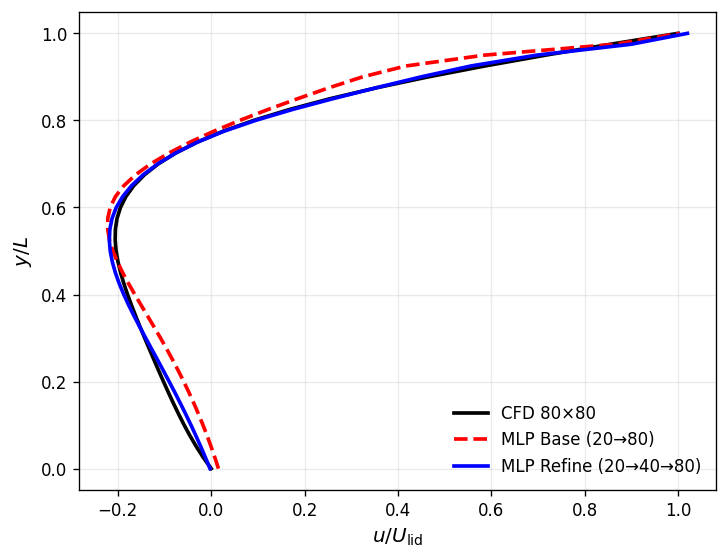

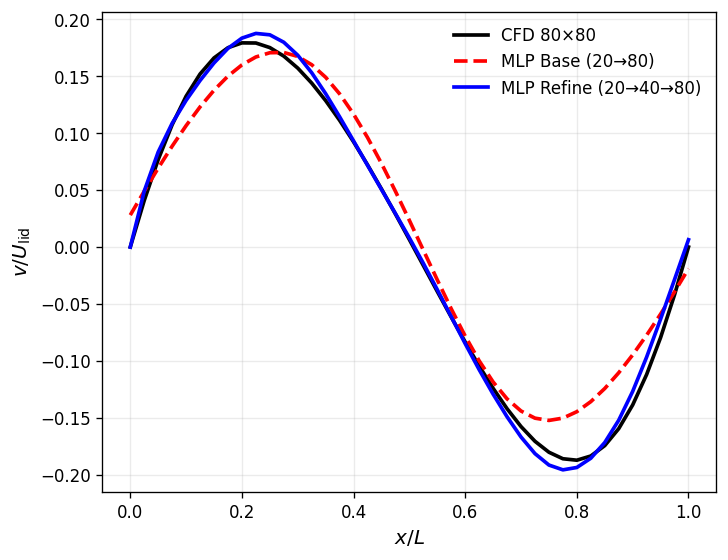

Figuras salvas em: /home/matheus/Documentos/Mestrado/Pesquisa/Lid_driven_cavity/outputs/figures/cavity_ml_profiles


In [34]:
# --- Geração de figuras dos perfis u(y) e v(x) comparando CFD 80x80, MLP base e MLP refiner ---
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# ---------------- Paths ----------------
DATA_80 = Path("/home/matheus/Documentos/Mestrado/Pesquisa/Lid_driven_cavity/data/prepared/cavity_80/cavity_80_full_norm.parquet")

MODEL_BASE   = Path("/home/matheus/Documentos/Mestrado/Pesquisa/Lid_driven_cavity/outputs/models/mlp_uv_cavity20.pt")
MODEL_REFINE = Path("/home/matheus/Documentos/Mestrado/Pesquisa/Lid_driven_cavity/outputs/models/mlp_uv_refiner.pt")

OUT_DIR = Path("/home/matheus/Documentos/Mestrado/Pesquisa/Lid_driven_cavity/outputs/figures/cavity_ml_profiles")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ---------------- Util ----------------
def load_model(path, in_dim):
    model = MLP(in_dim=in_dim, out_dim=2, hidden=128, depth=4, act="tanh").to(DEVICE)
    ckpt = torch.load(path, map_location=DEVICE)
    model.load_state_dict(ckpt["state_dict"])
    model.eval()
    return model


def extract_centerline(df, axis="x", value=0.5):
    """
    axis = 'x' -> extrai linha x = value, retorna ordenado em y
    axis = 'y' -> extrai linha y = value, retorna ordenado em x
    """
    coord = f"{axis}N"
    other = "yN" if axis == "x" else "xN"

    vals = np.sort(df[coord].unique())
    dval = np.min(np.diff(vals)) if len(vals) > 1 else 1e-3
    tol = dval / 2 + 1e-12

    line = df[np.abs(df[coord] - value) <= tol].copy()
    line = line.sort_values(other)

    return line


# ---------------- Main ----------------
def main():
    df80 = pd.read_parquet(DATA_80)

    base = load_model(MODEL_BASE, in_dim=2)
    refi = load_model(MODEL_REFINE, in_dim=4)

    # ==========================================================
    # Perfil u(y) em x/L = 0.5
    # ==========================================================
    line_x = extract_centerline(df80, axis="x", value=0.5)

    X_xy = torch.tensor(
        line_x[["xN", "yN"]].to_numpy(),
        dtype=torch.float32, device=DEVICE
    )

    y = line_x["yN"].to_numpy()
    u_ref = line_x["uN"].to_numpy()

    with torch.no_grad():
        pred_base = base(X_xy)
        Xin = torch.cat([X_xy, pred_base], dim=1)
        delta = refi(Xin)
        pred_ref = pred_base + delta

    u_base = pred_base[:, 0].cpu().numpy()
    u_refi = pred_ref[:, 0].cpu().numpy()

    plt.figure(figsize=(6.2, 4.8))
    plt.plot(u_ref, y, "k-",  lw=2.2, label="CFD 80×80")
    plt.plot(u_base, y, "r--", lw=2.2, label="MLP Base (20→80)")
    plt.plot(u_refi, y, "b-",  lw=2.2, label="MLP Refine (20→40→80)")
    plt.xlabel(r"$u/U_{\mathrm{lid}}$")
    plt.ylabel(r"$y/L$")
    plt.grid(True, alpha=0.25)
    plt.legend(frameon=False)
    plt.tight_layout()
    plt.savefig(OUT_DIR / "profile_u_x05_ml.pdf", dpi=300)
    plt.show()

    # ==========================================================
    # Perfil v(x) em y/L = 0.5
    # ==========================================================
    line_y = extract_centerline(df80, axis="y", value=0.5)

    X_xy = torch.tensor(
        line_y[["xN", "yN"]].to_numpy(),
        dtype=torch.float32, device=DEVICE
    )

    x = line_y["xN"].to_numpy()
    v_ref = line_y["vN"].to_numpy()

    with torch.no_grad():
        pred_base = base(X_xy)
        Xin = torch.cat([X_xy, pred_base], dim=1)
        delta = refi(Xin)
        pred_ref = pred_base + delta

    v_base = pred_base[:, 1].cpu().numpy()
    v_refi = pred_ref[:, 1].cpu().numpy()

    plt.figure(figsize=(6.2, 4.8))
    plt.plot(x, v_ref, "k-",  lw=2.2, label="CFD 80×80")
    plt.plot(x, v_base, "r--", lw=2.2, label="MLP Base (20→80)")
    plt.plot(x, v_refi, "b-",  lw=2.2, label="MLP Refine (20→40→80)")
    plt.xlabel(r"$x/L$")
    plt.ylabel(r"$v/U_{\mathrm{lid}}$")
    plt.grid(True, alpha=0.25)
    plt.legend(frameon=False)
    plt.tight_layout()
    plt.savefig(OUT_DIR / "profile_v_y05_ml.pdf", dpi=300)
    plt.show()

    print("Figuras salvas em:", OUT_DIR)


if __name__ == "__main__":
    main()


## Visualização de divergência física

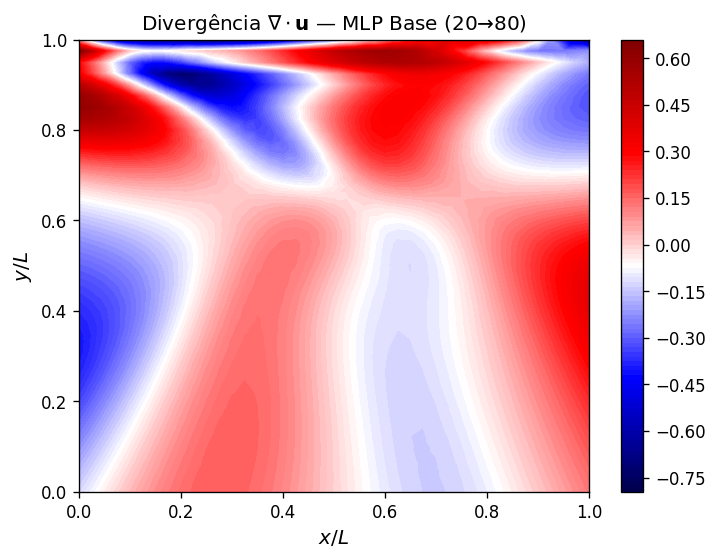

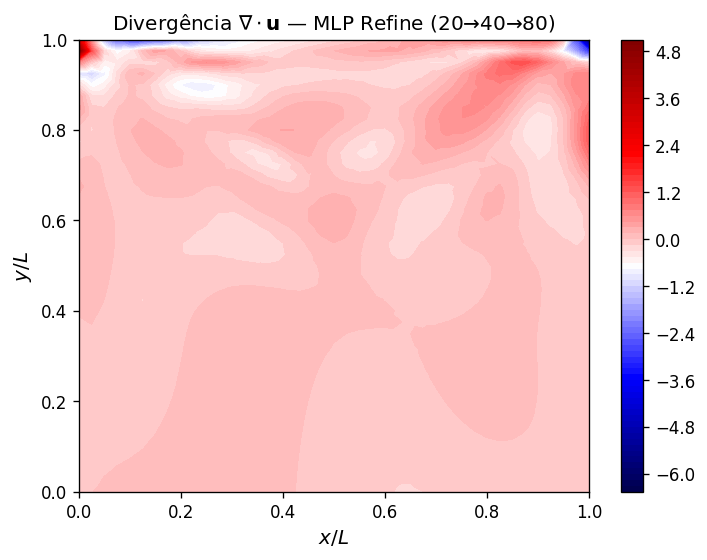

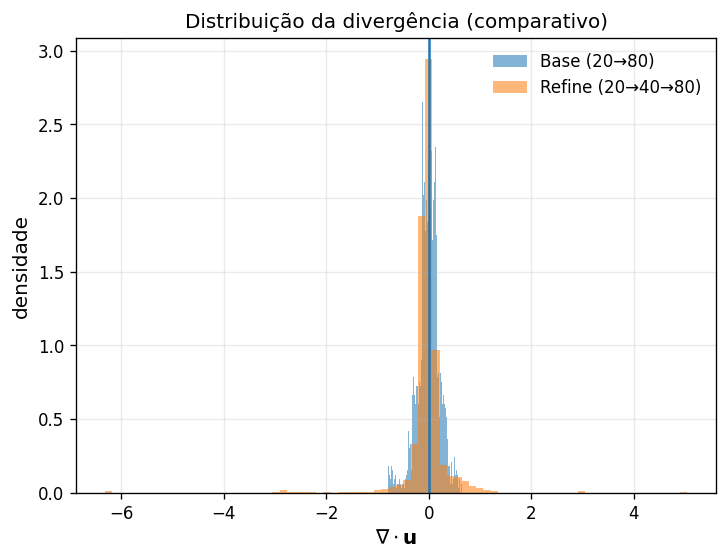

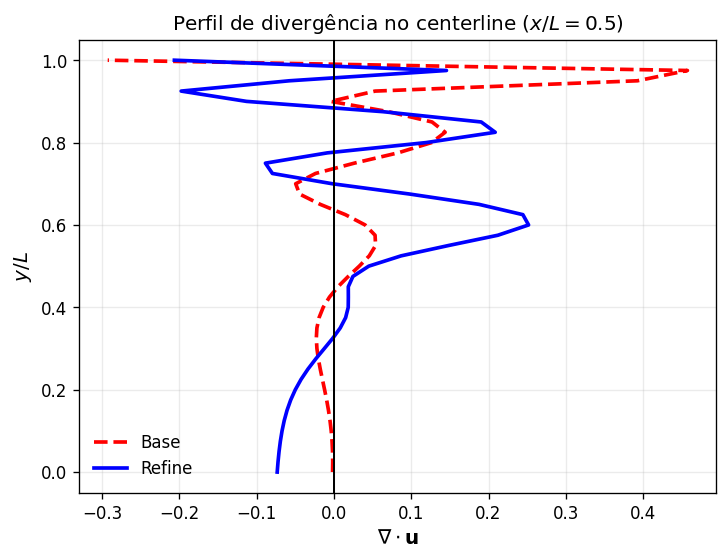

L2(div) BASE  : 2.160301e-01
L2(div) REFINE: 4.754136e-01
Figuras salvas em: /home/matheus/Documentos/Mestrado/Pesquisa/Lid_driven_cavity/outputs/figures/cavity_ml_profiles


In [35]:
# --- Geração de figuras dos mapas de divergência comparando MLP base e MLP refiner ---
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# ---------------- Paths ----------------
DATA_80 = Path("/home/matheus/Documentos/Mestrado/Pesquisa/Lid_driven_cavity/data/prepared/cavity_80/cavity_80_full_norm.parquet")

MODEL_BASE   = Path("/home/matheus/Documentos/Mestrado/Pesquisa/Lid_driven_cavity/outputs/models/mlp_uv_cavity20.pt")
MODEL_REFINE = Path("/home/matheus/Documentos/Mestrado/Pesquisa/Lid_driven_cavity/outputs/models/mlp_uv_refiner.pt")

OUT_DIR = Path("/home/matheus/Documentos/Mestrado/Pesquisa/Lid_driven_cavity/outputs/figures/cavity_ml_profiles")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ---------------- Util ----------------
def load_model(path, in_dim, out_dim=2):
    model = MLP(in_dim=in_dim, out_dim=out_dim, hidden=128, depth=4, act="tanh").to(DEVICE)
    ckpt = torch.load(path, map_location=DEVICE)
    model.load_state_dict(ckpt["state_dict"])
    model.eval()
    return model

def divergence_from_uv_model(uv_model, X):
    """
    uv_model: função/nn.Module que recebe X=(N,2) e retorna (N,2) = (u,v)
    X: torch tensor (N,2) no DEVICE
    Retorna div (N,) em numpy
    """
    Xg = X.detach().clone().requires_grad_(True)
    uv = uv_model(Xg)
    u = uv[:, 0:1]
    v = uv[:, 1:2]

    # autograd: du/dx, dv/dy
    du = torch.autograd.grad(u, Xg, grad_outputs=torch.ones_like(u), retain_graph=True)[0]
    dv = torch.autograd.grad(v, Xg, grad_outputs=torch.ones_like(v), retain_graph=False)[0]

    div = du[:, 0:1] + dv[:, 1:2]  # du/dx + dv/dy
    return div.detach().cpu().numpy().ravel()

def plot_tricontour(x, y, z, title, out_path, cmap="seismic", levels=100):
    plt.figure(figsize=(6.2, 4.8))
    sc = plt.tricontourf(x, y, z, levels=levels, cmap=cmap)
    plt.colorbar(sc)
    plt.xlabel(r"$x/L$")
    plt.ylabel(r"$y/L$")
    plt.title(title)
    plt.tight_layout()
    plt.savefig(out_path, bbox_inches="tight")
    plt.show()
    plt.close()

def extract_centerline(df, axis="x", value=0.5):
    coord = f"{axis}N"
    other = "yN" if axis == "x" else "xN"

    vals = np.sort(df[coord].unique())
    dval = np.min(np.diff(vals)) if len(vals) > 1 else 1e-3
    tol = dval / 2 + 1e-12

    line = df[np.abs(df[coord] - value) <= tol].copy()
    line = line.sort_values(other)
    return line

# ---------------- Main ----------------
def main():
    df80 = pd.read_parquet(DATA_80)

    # Coordenadas
    x = df80["xN"].to_numpy()
    y = df80["yN"].to_numpy()

    # Tensores
    X = torch.tensor(df80[["xN", "yN"]].to_numpy(), dtype=torch.float32, device=DEVICE)

    # Modelos
    base = load_model(MODEL_BASE, in_dim=2, out_dim=2)
    refi = load_model(MODEL_REFINE, in_dim=4, out_dim=2)

    # Funções para gerar uv
    def uv_base(X_in):
        return base(X_in)

    def uv_refine(X_in):
        # pred = base(x,y), delta = refiner([x,y,u,v])
        pred = base(X_in)
        Xin  = torch.cat([X_in, pred], dim=1)  # (N,4)
        d    = refi(Xin)                       # (N,2)
        return pred + d

    # ---------------- Divergência ----------------
    div_base = divergence_from_uv_model(uv_base, X)
    div_refi = divergence_from_uv_model(uv_refine, X)

    # ---------------- Mapas 2D ----------------
    plot_tricontour(
        x, y, div_base,
        title=r"Divergência $\nabla \cdot \mathbf{u}$ — MLP Base (20→80)",
        out_path=OUT_DIR / "div_map_base.pdf",
        cmap="seismic"
    )

    plot_tricontour(
        x, y, div_refi,
        title=r"Divergência $\nabla \cdot \mathbf{u}$ — MLP Refine (20→40→80)",
        out_path=OUT_DIR / "div_map_refine.pdf",
        cmap="seismic"
    )

    # ---------------- Histograma comparativo ----------------
    plt.figure(figsize=(6.2, 4.8))
    plt.hist(div_base, bins=80, alpha=0.55, density=True, label="Base (20→80)")
    plt.hist(div_refi, bins=80, alpha=0.55, density=True, label="Refine (20→40→80)")
    plt.axvline(0.0, linewidth=1.5)
    plt.xlabel(r"$\nabla \cdot \mathbf{u}$")
    plt.ylabel("densidade")
    plt.title("Distribuição da divergência (comparativo)")
    plt.grid(True, alpha=0.25)
    plt.legend(frameon=False)
    plt.tight_layout()
    plt.savefig(OUT_DIR / "div_hist_base_vs_refine.pdf", bbox_inches="tight")
    plt.show()
    plt.close()

    # ---------------- Perfil 1D da divergência (centerline x=0.5) ----------------
    line = extract_centerline(df80, axis="x", value=0.5)
    Xl = torch.tensor(line[["xN", "yN"]].to_numpy(), dtype=torch.float32, device=DEVICE)
    yline = line["yN"].to_numpy()

    div_base_line = divergence_from_uv_model(uv_base, Xl)
    div_refi_line = divergence_from_uv_model(uv_refine, Xl)

    plt.figure(figsize=(6.2, 4.8))
    plt.plot(div_base_line, yline, "r--", lw=2.2, label="Base")
    plt.plot(div_refi_line, yline, "b-",  lw=2.2, label="Refine")
    plt.axvline(0.0, color="k", lw=1.2)
    plt.xlabel(r"$\nabla \cdot \mathbf{u}$")
    plt.ylabel(r"$y/L$")
    plt.title(r"Perfil de divergência no centerline ($x/L=0.5$)")
    plt.grid(True, alpha=0.25)
    plt.legend(frameon=False)
    plt.tight_layout()
    plt.savefig(OUT_DIR / "div_profile_x05_base_vs_refine.pdf", bbox_inches="tight")
    plt.show()
    plt.close()

    # Métricas agregadas (pra log)
    l2_base = np.sqrt(np.mean(div_base**2))
    l2_refi = np.sqrt(np.mean(div_refi**2))
    print("L2(div) BASE  :", f"{l2_base:.6e}")
    print("L2(div) REFINE:", f"{l2_refi:.6e}")
    print("Figuras salvas em:", OUT_DIR)

if __name__ == "__main__":
    main()


Apesar dos avanços obtidos com modelos puramente orientados a dados, observa-se que a ausência de restrições físicas explícitas resulta em violações locais da condição de incompressibilidade. Dessa forma, propõe-se a introdução de Physics-Informed Neural Networks como forma de incorporar as equações governantes diretamente no processo de aprendizado.

# Modelo PINN

In [75]:
# PINN híbrido com MLP base + PINN corretor delta(u,v)
# ---------------- Utils ----------------
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# ---------------- Utils ----------------
def to_tensor(a):
    return torch.tensor(a, dtype=torch.float32, device=DEVICE)

def get_npz_key(z, *candidates):
    for k in candidates:
        if k in z:
            return k
    raise KeyError(f"Nenhuma das chaves {candidates} encontrada. Chaves disponíveis: {list(z.keys())}")

# ---------------- Modelos ----------------
class MLP(nn.Module):
    def __init__(self, in_dim=4, out_dim=2, hidden=128, depth=4, act="tanh"):
        super().__init__()
        acts = {"tanh": nn.Tanh(), "relu": nn.ReLU(), "gelu": nn.GELU(), "silu": nn.SiLU()}
        a = acts.get(act.lower(), nn.Tanh())
        layers = [nn.Linear(in_dim, hidden), a]
        for _ in range(depth - 1):
            layers += [nn.Linear(hidden, hidden), a]
        layers += [nn.Linear(hidden, out_dim)]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

class PINN_DUV(nn.Module):
    def __init__(self, hidden=128, depth=4, act="tanh"):
        super().__init__()
        acts = {"tanh": nn.Tanh(), "relu": nn.ReLU(), "gelu": nn.GELU(), "silu": nn.SiLU()}
        a = acts.get(act.lower(), nn.Tanh())
        layers = [nn.Linear(2, hidden), a]
        for _ in range(depth - 1):
            layers += [nn.Linear(hidden, hidden), a]
        layers += [nn.Linear(hidden, 2)]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

def continuity_residual_hybrid(delta_model: nn.Module, pinn: nn.Module, X: torch.Tensor, U_base: torch.Tensor):
    """
    div(U_final) = d(u_mlp + du_pinn)/dx + d(v_mlp + dv_pinn)/dy
    U_mlp(X) = U_base + delta_model([X, U_base])
    """
    if not X.requires_grad:
        X = X.detach().clone().requires_grad_(True)

    U_mlp = U_base + delta_model(torch.cat([X, U_base], dim=1))  # (N,2)
    duv = pinn(X)                                                # (N,2)

    u = U_mlp[:, 0:1] + duv[:, 0:1]
    v = U_mlp[:, 1:2] + duv[:, 1:2]

    gu = torch.autograd.grad(u, X, torch.ones_like(u), retain_graph=True, create_graph=True)[0]
    gv = torch.autograd.grad(v, X, torch.ones_like(v), retain_graph=True, create_graph=True)[0]
    return gu[:, 0:1] + gv[:, 1:2]

def smooth_loss(pinn: nn.Module, X: torch.Tensor):
    """
    Penaliza gradiente de Δu e Δv (suaviza correção e reduz MAE).
    """
    Xg = X.detach().clone().requires_grad_(True)
    duv = pinn(Xg)
    du = duv[:, 0:1]
    dv = duv[:, 1:2]

    gdu = torch.autograd.grad(du, Xg, torch.ones_like(du), retain_graph=True, create_graph=True)[0]
    gdv = torch.autograd.grad(dv, Xg, torch.ones_like(dv), retain_graph=True, create_graph=True)[0]
    return torch.mean(gdu**2) + torch.mean(gdv**2)


@torch.no_grad()
def mlp_base_uv(delta_model, X_xy, u_c, v_c, p_c):
    """
    Base = coarse + delta_MLP em um conjunto de pontos.
    X_xy: (N,2)
    u_c,v_c,p_c: (N,1)
    """
    X_in = torch.cat([X_xy, u_c, v_c, p_c], dim=1)  # (N,5)
    d = delta_model(X_in)
    du = d[:, 0:1]
    dv = d[:, 1:2]
    u_hat = u_c + du
    v_hat = v_c + dv
    return u_hat, v_hat


In [82]:
# ---------------- Paths ----------------
NPZ_PACK = Path("/home/matheus/Documentos/Mestrado/Pesquisa/Lid_driven_cavity/data/prepared/cavity_20/cavity_20_train_pack.npz")
DELTA_DATA = Path("/home/matheus/Documentos/Mestrado/Pesquisa/Lid_driven_cavity/data/prepared/cavity20_base_to_40_delta.npz")
DELTA_MODEL = Path("/home/matheus/Documentos/Mestrado/Pesquisa/Lid_driven_cavity/outputs/models/mlp_uv_refiner.pt")
OUT_PINN = Path("/home/matheus/Documentos/Mestrado/Pesquisa/Lid_driven_cavity/outputs/models/pinn_uv_hybrid.pt")
OUT_PINN.parent.mkdir(parents=True, exist_ok=True)

# ---------------- Hiperparâmetros ----------------
EPOCHS = 5000
LR = 1e-3

N_BC = None
N_DATA = 3000  # 2000~8000

# pesos fixos
LAMBDA_BC = 10.0
LAMBDA_REG = 1e-6

# suavidade do delta (muito útil p/ MAE)
LAMBDA_SMOOTH = 5e-2  # teste 1e-3, 1e-2, 5e-2

# currículo (duas fases)
PHASE_FRAC = 0.4
E_PHASE = int(EPOCHS * PHASE_FRAC)

# Fase A: cola no ref, física leve
REF_A = 5.0
CONT_A = 5.0

# Fase B: aperta física, mantém ref menor
REF_B = 3.0
CONT_B = 12.0

def lambdas(epoch: int):
    if epoch <= E_PHASE:
        return CONT_A, REF_A
    return CONT_B, REF_B

# ---- carrega pack 20 (BC) ----
pack = np.load(NPZ_PACK)
kXbc = get_npz_key(pack, "X_bc", "xbc", "Xb")
X_bc = to_tensor(pack[kXbc])  # (Nbc,2)

# ---- carrega delta-data (grid 40) ----
dnpz = np.load(DELTA_DATA)
X_all = to_tensor(dnpz["X"])            # (N,2)
U_base_all = to_tensor(dnpz["U_base"])  # (N,2)
Delta_all = to_tensor(dnpz["Delta"])    # (N,2) ou (N,>=2)
if Delta_all.shape[1] > 2:
    Delta_all = Delta_all[:, :2]

U_ref_all = (U_base_all + Delta_all).detach()
Nd = X_all.shape[0]

# ---- carrega MLP refiner (congelado) ----
delta_model = MLP(in_dim=4, out_dim=2, hidden=128, depth=4, act="tanh").to(DEVICE)
ckpt = torch.load(DELTA_MODEL, map_location=DEVICE)
sd = ckpt["state_dict"] if isinstance(ckpt, dict) and "state_dict" in ckpt else ckpt
delta_model.load_state_dict(sd)
delta_model.eval()
for p in delta_model.parameters():
    p.requires_grad_(False)

# ---- cria PINN corretora ----
pinn = PINN_DUV(hidden=128, depth=4, act="tanh").to(DEVICE)
opt = torch.optim.Adam(pinn.parameters(), lr=LR)

bc_idx_all = torch.arange(len(X_bc), device=DEVICE)
data_idx_all = torch.arange(Nd, device=DEVICE)

for epoch in range(1, EPOCHS + 1):
    pinn.train()
    L_CONT, L_REF = lambdas(epoch)

    # --- sample BC ---
    if N_BC is None or N_BC >= len(bc_idx_all):
        sel_bc = bc_idx_all
    else:
        sel_bc = torch.randint(0, len(bc_idx_all), (N_BC,), device=DEVICE)
    Xb = X_bc[sel_bc]

    # --- sample data (grid 40) ---
    if N_DATA is None or N_DATA >= Nd:
        sel_d = data_idx_all
    else:
        sel_d = torch.randint(0, Nd, (N_DATA,), device=DEVICE)

    Xd = X_all[sel_d]
    Ubase = U_base_all[sel_d].detach()
    Uref = U_ref_all[sel_d].detach()

    # X com grad (para continuidade e smooth)
    Xd_g = Xd.detach().clone().requires_grad_(True)

    # --- forward ---
    duv_bc = pinn(Xb)
    duv_d = pinn(Xd_g)

    U_mlp = Ubase + delta_model(torch.cat([Xd_g, Ubase], dim=1))
    U_final = U_mlp + duv_d

    # --- losses ---
    loss_bc = torch.mean(duv_bc ** 2)
    loss_reg = torch.mean(duv_d ** 2)

    r_cont = continuity_residual_hybrid(delta_model, pinn, Xd_g, Ubase)
    loss_cont = torch.mean(r_cont ** 2)

    loss_ref = torch.mean((U_final - Uref) ** 2)

    loss_smooth = smooth_loss(pinn, Xd_g)

    loss = (
        LAMBDA_BC * loss_bc
        + L_CONT * loss_cont
        + L_REF * loss_ref
        + LAMBDA_REG * loss_reg
        + LAMBDA_SMOOTH * loss_smooth
    )

    opt.zero_grad(set_to_none=True)
    loss.backward()
    opt.step()

    if epoch % 200 == 0 or epoch == 1:
        print(
            f"epoch={epoch:4d} "
            f"loss={loss.item():.3e} "
            f"bc={loss_bc.item():.3e} "
            f"cont={loss_cont.item():.3e} "
            f"ref={loss_ref.item():.3e} "
            f"reg={loss_reg.item():.3e} "
            f"smooth={loss_smooth.item():.3e} "
            f"L_CONT={L_CONT:.2f} L_REF={L_REF:.2f}"
        )

torch.save({"state_dict": pinn.state_dict()}, OUT_PINN)
print("\nOK! PINN(delta) salva em:", OUT_PINN)

epoch=   1 loss=9.312e-01 bc=9.093e-03 cont=1.586e-01 ref=9.413e-03 reg=8.836e-03 smooth=4.094e-03 L_CONT=5.00 L_REF=5.00
epoch= 200 loss=6.841e-01 bc=4.625e-04 cont=1.352e-01 ref=6.524e-04 reg=3.184e-04 smooth=8.630e-03 L_CONT=5.00 L_REF=5.00
epoch= 400 loss=5.199e-01 bc=4.058e-04 cont=1.022e-01 ref=8.218e-04 reg=2.920e-04 smooth=1.983e-02 L_CONT=5.00 L_REF=5.00
epoch= 600 loss=5.309e-01 bc=5.573e-04 cont=1.040e-01 ref=8.545e-04 reg=3.776e-04 smooth=2.118e-02 L_CONT=5.00 L_REF=5.00
epoch= 800 loss=4.099e-01 bc=4.577e-04 cont=7.970e-02 ref=1.041e-03 reg=4.220e-04 smooth=3.270e-02 L_CONT=5.00 L_REF=5.00
epoch=1000 loss=2.770e-01 bc=6.567e-04 cont=5.248e-02 ref=1.170e-03 reg=4.928e-04 smooth=4.368e-02 L_CONT=5.00 L_REF=5.00
epoch=1200 loss=2.853e-01 bc=4.650e-04 cont=5.463e-02 ref=1.032e-03 reg=5.770e-04 smooth=4.733e-02 L_CONT=5.00 L_REF=5.00
epoch=1400 loss=2.252e-01 bc=5.200e-04 cont=4.232e-02 ref=1.086e-03 reg=4.629e-04 smooth=5.982e-02 L_CONT=5.00 L_REF=5.00
epoch=1600 loss=2.216e-0

In [83]:
# --- Avaliação do PINN híbrido com MLP base + PINN corretor delta(u,v) ---
DELTA_DATA = Path("/home/matheus/Documentos/Mestrado/Pesquisa/Lid_driven_cavity/data/prepared/cavity20_base_to_40_delta.npz")
MLP_PATH   = Path("/home/matheus/Documentos/Mestrado/Pesquisa/Lid_driven_cavity/outputs/models/mlp_uv_refiner.pt")
PINN_PATH  = Path("/home/matheus/Documentos/Mestrado/Pesquisa/Lid_driven_cavity/outputs/models/pinn_uv_hybrid.pt")


def div_rms(Ux, Uy, X):
    gu = torch.autograd.grad(Ux, X, torch.ones_like(Ux), retain_graph=True, create_graph=False)[0]
    gv = torch.autograd.grad(Uy, X, torch.ones_like(Uy), retain_graph=False, create_graph=False)[0]
    div = gu[:,0:1] + gv[:,1:2]
    return torch.sqrt(torch.mean(div**2))


d = np.load(DELTA_DATA)
X0 = torch.tensor(d["X"], dtype=torch.float32, device=DEVICE)
U_base = torch.tensor(d["U_base"], dtype=torch.float32, device=DEVICE)

# MLP
mlp = MLP(in_dim=4, out_dim=2, hidden=128, depth=4, act="tanh").to(DEVICE)
ckpt = torch.load(MLP_PATH, map_location=DEVICE)
sd = ckpt["state_dict"] if isinstance(ckpt, dict) and "state_dict" in ckpt else ckpt
mlp.load_state_dict(sd)
mlp.eval()
for p in mlp.parameters():
    p.requires_grad_(False)

# PINN(delta)
pinn = PINN_DUV().to(DEVICE)
ckpt2 = torch.load(PINN_PATH, map_location=DEVICE)
sd2 = ckpt2["state_dict"] if isinstance(ckpt2, dict) and "state_dict" in ckpt2 else ckpt2
pinn.load_state_dict(sd2)
pinn.eval()

def div_rms_from_field(U, X, retain_graph):
    # U: (N,2), X: (N,2) com requires_grad=True
    u = U[:, 0:1]
    v = U[:, 1:2]
    gu = torch.autograd.grad(u, X, torch.ones_like(u), retain_graph=True,  create_graph=False)[0]
    gv = torch.autograd.grad(v, X, torch.ones_like(v), retain_graph=retain_graph, create_graph=False)[0]
    div = gu[:, 0:1] + gv[:, 1:2]
    return torch.sqrt(torch.mean(div**2))

# --- Avaliação ---
X = X0.detach().clone().requires_grad_(True)
U_base_g = U_base.detach()

U_mlp = U_base_g + mlp(torch.cat([X, U_base_g], dim=1))
duv = pinn(X)
U_final = U_mlp + duv

# mantém o grafo na primeira, libera na segunda
div_mlp = div_rms_from_field(U_mlp, X, retain_graph=True).item()
div_fin = div_rms_from_field(U_final, X, retain_graph=False).item()

corr_rms = torch.sqrt(torch.mean(duv**2)).item()

print("=== Avaliação híbrida (40×40) ===")
print(f"N pontos: {X.shape[0]}")
print(f"L2(div) - RMS (MLP):      {div_mlp:.6e}")
print(f"L2(div) - RMS (MLP+PINN): {div_fin:.6e}")
print(f"RMS correção PINN:        {corr_rms:.6e}")
print(f"Melhora div (x):          {div_mlp / max(div_fin, 1e-30):.2f}x")


=== Avaliação híbrida (40×40) ===
N pontos: 3686
L2(div) - RMS (MLP):      3.851117e-01
L2(div) - RMS (MLP+PINN): 4.530454e-02
RMS correção PINN:        2.140853e-02
Melhora div (x):          8.50x


In [84]:
# --- Comparação de erro do MLP base vs PINN híbrido (MLP + PINN delta) ---
DELTA_DATA = Path("/home/matheus/Documentos/Mestrado/Pesquisa/Lid_driven_cavity/data/prepared/cavity20_base_to_40_delta.npz")
MLP_PATH   = Path("/home/matheus/Documentos/Mestrado/Pesquisa/Lid_driven_cavity/outputs/models/mlp_uv_refiner.pt")
PINN_PATH  = Path("/home/matheus/Documentos/Mestrado/Pesquisa/Lid_driven_cavity/outputs/models/pinn_uv_hybrid.pt")

def rmse(a, b): return torch.sqrt(torch.mean((a - b) ** 2)).item()
def mae(a, b):  return torch.mean(torch.abs(a - b)).item()

d = np.load(DELTA_DATA)
X = torch.tensor(d["X"], dtype=torch.float32, device=DEVICE)
U_base = torch.tensor(d["U_base"], dtype=torch.float32, device=DEVICE)
Delta = torch.tensor(d["Delta"], dtype=torch.float32, device=DEVICE)
if Delta.shape[1] > 2:
    Delta = Delta[:, :2]

U_ref = U_base + Delta

mlp = MLP(in_dim=4, out_dim=2, hidden=128, depth=4, act="tanh").to(DEVICE)
ckpt = torch.load(MLP_PATH, map_location=DEVICE)
sd = ckpt["state_dict"] if isinstance(ckpt, dict) and "state_dict" in ckpt else ckpt
mlp.load_state_dict(sd)
mlp.eval()
for p in mlp.parameters(): p.requires_grad_(False)

pinn = PINN_DUV(hidden=128, depth=4, act="tanh").to(DEVICE)
ckpt2 = torch.load(PINN_PATH, map_location=DEVICE)
sd2 = ckpt2["state_dict"] if isinstance(ckpt2, dict) and "state_dict" in ckpt2 else ckpt2
pinn.load_state_dict(sd2)
pinn.eval()

with torch.no_grad():
    U_base_g = U_base.detach()
    U_mlp = U_base_g + mlp(torch.cat([X, U_base_g], dim=1))
    U_final = U_mlp + pinn(X)

print("=== Erro vs ref40 (U_base + Delta) ===")
print(f"RMSE MLP:      {rmse(U_mlp, U_ref):.6e}")
print(f"RMSE Híbrido:  {rmse(U_final, U_ref):.6e}")
print(f" MAE MLP:      {mae(U_mlp, U_ref):.6e}")
print(f" MAE Híbrido:  {mae(U_final, U_ref):.6e}")

=== Erro vs ref40 (U_base + Delta) ===
RMSE MLP:      2.340497e-02
RMSE Híbrido:  3.262768e-02
 MAE MLP:      9.643311e-03
 MAE Híbrido:  1.962770e-02


In [ ]:
# -------- paths ----------
DELTA_DATA = Path("/home/matheus/Documentos/Mestrado/Pesquisa/Lid_driven_cavity/data/prepared/cavity20_base_to_40_delta.npz")
MLP_PATH   = Path("/home/matheus/Documentos/Mestrado/Pesquisa/Lid_driven_cavity/outputs/models/mlp_uv_refiner.pt")
PINN_PATH  = Path("/home/matheus/Documentos/Mestrado/Pesquisa/Lid_driven_cavity/outputs/models/pinn_uv_hybrid.pt")
OUT_DIR    = Path("/home/matheus/Documentos/Mestrado/Pesquisa/Lid_driven_cavity/outputs/figs_hybrid_40")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# -------- divergence utils ----------
def div_field(U, X, retain_graph=False):
    """
    U: (N,2) tensor; X: (N,2) requires_grad=True
    Retorna div: (N,1)
    """
    u = U[:, 0:1]
    v = U[:, 1:2]
    gu = torch.autograd.grad(u, X, torch.ones_like(u), retain_graph=True,  create_graph=False)[0]
    gv = torch.autograd.grad(v, X, torch.ones_like(v), retain_graph=retain_graph, create_graph=False)[0]
    div = gu[:, 0:1] + gv[:, 1:2]
    return div

def div_rms(U, X, retain_graph=False):
    d = div_field(U, X, retain_graph=retain_graph)
    return torch.sqrt(torch.mean(d**2)).item(), d

# -------- plot helpers ----------
def savefig(name):
    p = OUT_DIR / name
    plt.tight_layout()
    plt.savefig(p, dpi=200)
    plt.close()
    print("salvo:", p)

def tricontour_map(x, y, z, title, fname, nlevels=40):
    plt.figure(figsize=(6,5))
    tcf = plt.tricontourf(x, y, z, levels=nlevels)
    plt.colorbar(tcf)
    plt.title(title)
    plt.xlabel("xN"); plt.ylabel("yN")
    savefig(fname)

def tricontour_diff(x, y, z1, z2, title, fname, nlevels=40):
    dz = z1 - z2
    tricontour_map(x, y, dz, title, fname, nlevels=nlevels)

def line_profile_nearest(x, y, val, x_target=None, y_target=None, tol=0.02):
    """
    Extrai perfil por 'banda' usando pontos próximos de x=x_target (vertical) ou y=y_target (horizontal).
    - Se x_target definido: seleciona |x-x_target|<=tol e ordena por y.
    - Se y_target definido: seleciona |y-y_target|<=tol e ordena por x.
    Retorna (s, v) onde s é y ou x.
    """
    if x_target is not None:
        m = np.abs(x - x_target) <= tol
        xs, ys, vs = x[m], y[m], val[m]
        idx = np.argsort(ys)
        return ys[idx], vs[idx]
    if y_target is not None:
        m = np.abs(y - y_target) <= tol
        xs, ys, vs = x[m], y[m], val[m]
        idx = np.argsort(xs)
        return xs[idx], vs[idx]
    raise ValueError("Defina x_target ou y_target")

def plot_profiles(x, y, U_ref, U_mlp, U_hyb, tol=0.02):
    # u(x=0.5, y)
    y1, uref = line_profile_nearest(x, y, U_ref[:,0], x_target=0.5, tol=tol)
    y2, umlp = line_profile_nearest(x, y, U_mlp[:,0], x_target=0.5, tol=tol)
    y3, uhyb = line_profile_nearest(x, y, U_hyb[:,0], x_target=0.5, tol=tol)

    plt.figure(figsize=(6,5))
    plt.plot(uref, y1, label="ref40")
    plt.plot(umlp, y2, label="MLP")
    plt.plot(uhyb, y3, label="Híbrido")
    plt.xlabel("u"); plt.ylabel("yN")
    plt.title(f"Perfil u em x=0.5 (tol={tol})")
    plt.legend()
    savefig("perfil_u_x05.png")

    # v(x, y=0.5)
    x1, vref = line_profile_nearest(x, y, U_ref[:,1], y_target=0.5, tol=tol)
    x2, vmlp = line_profile_nearest(x, y, U_mlp[:,1], y_target=0.5, tol=tol)
    x3, vhyb = line_profile_nearest(x, y, U_hyb[:,1], y_target=0.5, tol=tol)

    plt.figure(figsize=(6,5))
    plt.plot(x1, vref, label="ref40")
    plt.plot(x2, vmlp, label="MLP")
    plt.plot(x3, vhyb, label="Híbrido")
    plt.xlabel("xN"); plt.ylabel("v")
    plt.title(f"Perfil v em y=0.5 (tol={tol})")
    plt.legend()
    savefig("perfil_v_y05.png")

def plot_hist_cdf(abs_div_mlp, abs_div_hyb):
    # Hist
    plt.figure(figsize=(6,5))
    plt.hist(abs_div_mlp, bins=60, alpha=0.6, label="MLP", density=True)
    plt.hist(abs_div_hyb, bins=60, alpha=0.6, label="Híbrido", density=True)
    plt.yscale("log")
    plt.xlabel("|div|"); plt.ylabel("densidade (log)")
    plt.title("Histograma de |div|")
    plt.legend()
    savefig("hist_abs_div.png")

    # CDF
    def cdf(a):
        a = np.sort(a)
        p = np.linspace(0, 1, len(a))
        return a, p

    x1, p1 = cdf(abs_div_mlp)
    x2, p2 = cdf(abs_div_hyb)

    plt.figure(figsize=(6,5))
    plt.plot(x1, p1, label="MLP")
    plt.plot(x2, p2, label="Híbrido")
    plt.xscale("log")
    plt.xlabel("|div| (log)"); plt.ylabel("CDF")
    plt.title("CDF de |div| (quanto menor, melhor)")
    plt.legend()
    savefig("cdf_abs_div.png")


# --- load data ---
d = np.load(DELTA_DATA)
X = torch.tensor(d["X"], dtype=torch.float32, device=DEVICE)
U_base = torch.tensor(d["U_base"], dtype=torch.float32, device=DEVICE)
Delta = torch.tensor(d["Delta"], dtype=torch.float32, device=DEVICE)
if Delta.shape[1] > 2:
    Delta = Delta[:, :2]
U_ref = U_base + Delta

# numpy coords for plotting
x = X[:,0].detach().cpu().numpy()
y = X[:,1].detach().cpu().numpy()

# --- load models ---
mlp = MLP(in_dim=4, out_dim=2, hidden=128, depth=4, act="tanh").to(DEVICE)
ckpt = torch.load(MLP_PATH, map_location=DEVICE)
sd = ckpt["state_dict"] if isinstance(ckpt, dict) and "state_dict" in ckpt else ckpt
mlp.load_state_dict(sd)
mlp.eval()
for p in mlp.parameters():
    p.requires_grad_(False)

pinn = PINN_DUV(hidden=128, depth=4, act="tanh").to(DEVICE)
ckpt2 = torch.load(PINN_PATH, map_location=DEVICE)
sd2 = ckpt2["state_dict"] if isinstance(ckpt2, dict) and "state_dict" in ckpt2 else ckpt2
pinn.load_state_dict(sd2)
pinn.eval()

# --- infer fields ---
with torch.no_grad():
    U_base_g = U_base.detach()
    U_mlp = U_base_g + mlp(torch.cat([X, U_base_g], dim=1))
    U_hyb = U_mlp + pinn(X)

# --- errors (global) ---
rmse_mlp = rmse(U_mlp, U_ref)
rmse_hyb = rmse(U_hyb, U_ref)
mae_mlp  = mae(U_mlp, U_ref)
mae_hyb  = mae(U_hyb, U_ref)

# --- divergence (global) ---
Xg = X.detach().clone().requires_grad_(True)
# recomputa U_mlp e U_hyb com esse Xg pra garantir grafo
U_mlp_g = U_base.detach() + mlp(torch.cat([Xg, U_base.detach()], dim=1))
duv_g = pinn(Xg)
U_hyb_g = U_mlp_g + duv_g

div_mlp_rms, div_mlp = div_rms(U_mlp_g, Xg, retain_graph=True)
div_hyb_rms, div_hyb = div_rms(U_hyb_g, Xg, retain_graph=False)

# report
print("\n=== Métricas globais (ref40 = U_base + Delta) ===")
print(f"RMSE MLP:      {rmse_mlp:.6e}")
print(f"RMSE Híbrido:  {rmse_hyb:.6e}")
print(f" MAE MLP:      {mae_mlp:.6e}")
print(f" MAE Híbrido:  {mae_hyb:.6e}")
print("\n=== Incompressibilidade (div) ===")
print(f"L2(div) RMS (MLP):      {div_mlp_rms:.6e}")
print(f"L2(div) RMS (Híbrido):  {div_hyb_rms:.6e}")
print(f"Melhora div (x):        {div_mlp_rms / max(div_hyb_rms, 1e-30):.2f}x")

# ---- maps (u,v) ----
Uref_np = U_ref.detach().cpu().numpy()
Umlp_np = U_mlp.detach().cpu().numpy()
Uhyb_np = U_hyb.detach().cpu().numpy()

# erro magnitude
err_mlp = np.sqrt((Umlp_np[:,0]-Uref_np[:,0])**2 + (Umlp_np[:,1]-Uref_np[:,1])**2)
err_hyb = np.sqrt((Uhyb_np[:,0]-Uref_np[:,0])**2 + (Uhyb_np[:,1]-Uref_np[:,1])**2)

tricontour_map(x, y, err_mlp, "Erro |U_MLP - U_ref|", "map_err_mlp.png")
tricontour_map(x, y, err_hyb, "Erro |U_Híbrido - U_ref|", "map_err_hybrid.png")

# maps de u e v (opcional, mas útil)
tricontour_map(x, y, Umlp_np[:,0], "u (MLP)", "map_u_mlp.png")
tricontour_map(x, y, Uhyb_np[:,0], "u (Híbrido)", "map_u_hybrid.png")
tricontour_map(x, y, Uref_np[:,0], "u (ref40)", "map_u_ref.png")

tricontour_map(x, y, Umlp_np[:,1], "v (MLP)", "map_v_mlp.png")
tricontour_map(x, y, Uhyb_np[:,1], "v (Híbrido)", "map_v_hybrid.png")
tricontour_map(x, y, Uref_np[:,1], "v (ref40)", "map_v_ref.png")

# ---- div maps ----
div_mlp_np = div_mlp.detach().cpu().numpy().reshape(-1)
div_hyb_np = div_hyb.detach().cpu().numpy().reshape(-1)
tricontour_map(x, y, np.abs(div_mlp_np), "|div| (MLP)", "map_absdiv_mlp.png")
tricontour_map(x, y, np.abs(div_hyb_np), "|div| (Híbrido)", "map_absdiv_hybrid.png")
tricontour_diff(x, y, np.abs(div_mlp_np), np.abs(div_hyb_np), "|div| MLP - |div| Híbrido", "map_absdiv_diff.png")

# ---- profiles ----
plot_profiles(x, y, Uref_np, Umlp_np, Uhyb_np, tol=0.02)

# ---- hist/cdf of |div| ----
plot_hist_cdf(np.abs(div_mlp_np), np.abs(div_hyb_np))

# ---- resumo em txt ----
summary = OUT_DIR / "summary_metrics.txt"
with open(summary, "w") as f:
    f.write("=== Métricas globais (ref40 = U_base + Delta) ===\n")
    f.write(f"RMSE MLP:     {rmse_mlp:.6e}\n")
    f.write(f"RMSE Híbrido: {rmse_hyb:.6e}\n")
    f.write(f"MAE  MLP:     {mae_mlp:.6e}\n")
    f.write(f"MAE  Híbrido: {mae_hyb:.6e}\n\n")
    f.write("=== Incompressibilidade (div) ===\n")
    f.write(f"L2(div) RMS (MLP):     {div_mlp_rms:.6e}\n")
    f.write(f"L2(div) RMS (Híbrido): {div_hyb_rms:.6e}\n")
    f.write(f"Melhora div (x):       {div_mlp_rms / max(div_hyb_rms, 1e-30):.2f}x\n")
print("salvo:", summary)



=== Métricas globais (ref40 = U_base + Delta) ===
RMSE MLP:      2.340497e-02
RMSE Híbrido:  3.262768e-02
 MAE MLP:      9.643311e-03
 MAE Híbrido:  1.962770e-02

=== Incompressibilidade (div) ===
L2(div) RMS (MLP):      3.851117e-01
L2(div) RMS (Híbrido):  4.530454e-02
Melhora div (x):        8.50x
salvo: /home/matheus/Documentos/Mestrado/Pesquisa/Lid_driven_cavity/outputs/figs_hybrid_40/map_err_mlp.png
salvo: /home/matheus/Documentos/Mestrado/Pesquisa/Lid_driven_cavity/outputs/figs_hybrid_40/map_err_hybrid.png
salvo: /home/matheus/Documentos/Mestrado/Pesquisa/Lid_driven_cavity/outputs/figs_hybrid_40/map_u_mlp.png
salvo: /home/matheus/Documentos/Mestrado/Pesquisa/Lid_driven_cavity/outputs/figs_hybrid_40/map_u_hybrid.png
salvo: /home/matheus/Documentos/Mestrado/Pesquisa/Lid_driven_cavity/outputs/figs_hybrid_40/map_u_ref.png
salvo: /home/matheus/Documentos/Mestrado/Pesquisa/Lid_driven_cavity/outputs/figs_hybrid_40/map_v_mlp.png
salvo: /home/matheus/Documentos/Mestrado/Pesquisa/Lid_driv